<a href="https://colab.research.google.com/github/AliceFranca0/tcc-deteccao-fake-news-ptbr/blob/main/notebooks/Fase7_Explicabilidade_Painel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Ambiente

In [1]:
!pip install -q lime gradio transformers torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
from google.colab import drive
drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/TCC"

import os
os.makedirs(f"{BASE}/figuras", exist_ok=True)
print("Base:", BASE)

Mounted at /content/drive
Base: /content/drive/MyDrive/TCC


In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt

CORAL = "#EF476F"   # Fake / Random Forest
AZUL  = "#118AB2"   # Real / Logistic Regression
VERDE = "#06D6A0"   # BERTimbau

mpl.rcParams.update({
    "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.family": "sans-serif", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": "#073B4C",
    "axes.labelsize": 10.5, "axes.labelweight": "bold",
    "axes.edgecolor": "#999999", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": "#E6E6E6", "grid.linewidth": 0.7,
    "legend.frameon": False,
    "figure.facecolor": "white", "savefig.facecolor": "white",
})

## 2. Carregamento do classificador neural

O caminho abaixo aceita tanto a pasta local no Drive quanto o identificador de um repositório no Hugging Face Hub. Usar o Hub torna este notebook executável por qualquer pessoa, sem depender do Drive da autora.

In [4]:
CAMINHO_MODELO = f"{BASE}/modelos/modelo_bertimbau_final"
# Alternativa pública:
# CAMINHO_MODELO = "SEU-USUARIO/bertimbau-fake-news-ptbr"

import os
if CAMINHO_MODELO.startswith("/") and not os.path.exists(CAMINHO_MODELO):
    print("ATENÇÃO: modelo não encontrado em", CAMINHO_MODELO)
    print("Conteúdo de modelos/:", os.listdir(f"{BASE}/modelos") if os.path.exists(f"{BASE}/modelos") else "(pasta inexistente)")
else:
    print("Caminho válido.")

Caminho válido.


In [5]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

dispositivo = "cuda" if torch.cuda.is_available() else "cpu"

tok = AutoTokenizer.from_pretrained(CAMINHO_MODELO)
mod = AutoModelForSequenceClassification.from_pretrained(CAMINHO_MODELO).to(dispositivo).eval()

print("Modelo carregado em:", dispositivo)

Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

Modelo carregado em: cpu


In [6]:
import numpy as np

def prever_proba(textos):
    """Recebe lista de textos; devolve matriz de probabilidades [P(fake), P(real)]."""
    entradas = tok(list(textos), truncation=True, padding=True,
                   max_length=256, return_tensors="pt").to(dispositivo)
    with torch.no_grad():
        logits = mod(**entradas).logits
    return torch.softmax(logits, dim=-1).cpu().numpy()

# Teste de sanidade antes de prosseguir
print(prever_proba(["Ministério da Saúde confirma novo protocolo de vacinação."]).round(3))

[[0.002 0.998]]


## 3. Explicabilidade com LIME

O LIME (*Local Interpretable Model-agnostic Explanations*) perturba o texto de entrada, observa como a previsão muda e estima o peso de cada termo na decisão.

O parâmetro `num_samples` é reduzido para 500 (o padrão da biblioteca é 5000): cada amostra corresponde a uma inferência do BERT, e o valor padrão tornaria a explicação de um único texto excessivamente lenta.

In [7]:
from lime.lime_text import LimeTextExplainer
import pandas as pd

explicador = LimeTextExplainer(class_names=["Fake", "Real"])

df = pd.read_csv(f"{BASE}/dados/fakerecogna_bruto.csv")
df = df.dropna(subset=["Noticia", "Classe"]).reset_index(drop=True)
df["Classe"] = df["Classe"].astype(int)

exemplo_fake = df[df["Classe"] == 0]["Noticia"].iloc[0]
exemplo_real = df[df["Classe"] == 1]["Noticia"].iloc[0]

print("Exemplo FAKE:", exemplo_fake[:200], "\n")
print("Exemplo REAL:", exemplo_real[:200])

Exemplo FAKE: apagão vaticano papar presar acusação tráfico criança e fraude .. o papar francisco tuitou manhã o curador beaver confirmar o papar francisco equipar rede social agendar publicação e planejada anteced 

Exemplo REAL: o governar equador anunciar preparar cova coletiva cemitério enterrar morto coronavírus cidade guaiaquil país divulgar o sepultura ficar pronto o redar ecuavisa sepulcro construir homenagem s vítima o


In [8]:
exp_fake = explicador.explain_instance(exemplo_fake, prever_proba, num_features=15, num_samples=500)
exp_fake.show_in_notebook()

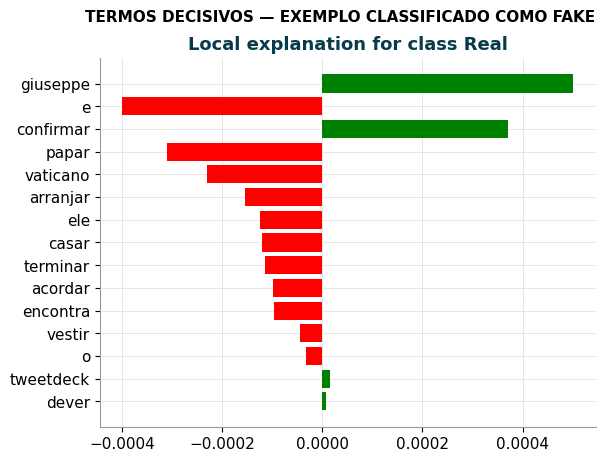

In [9]:
fig = exp_fake.as_pyplot_figure()
fig.suptitle("TERMOS DECISIVOS — EXEMPLO CLASSIFICADO COMO FAKE", fontsize=11, fontweight="bold")
fig.savefig(f"{BASE}/figuras/lime_exemplo_fake.png", dpi=300, bbox_inches="tight")
plt.show()

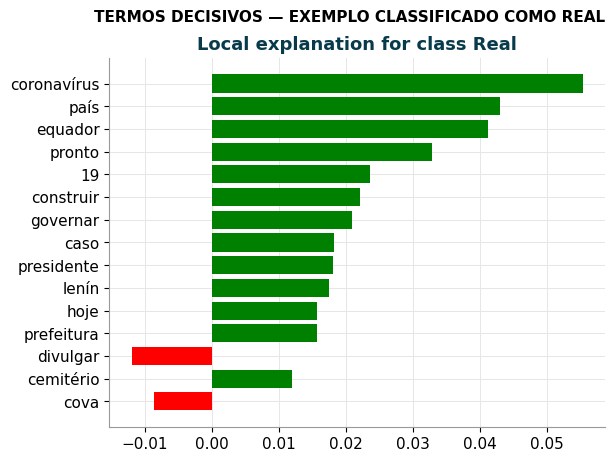

In [10]:
exp_real = explicador.explain_instance(exemplo_real, prever_proba, num_features=15, num_samples=500)
fig = exp_real.as_pyplot_figure()
fig.suptitle("TERMOS DECISIVOS — EXEMPLO CLASSIFICADO COMO REAL", fontsize=11, fontweight="bold")
fig.savefig(f"{BASE}/figuras/lime_exemplo_real.png", dpi=300, bbox_inches="tight")
plt.show()

1 erros em 200 amostras
Classe verdadeira: Fake



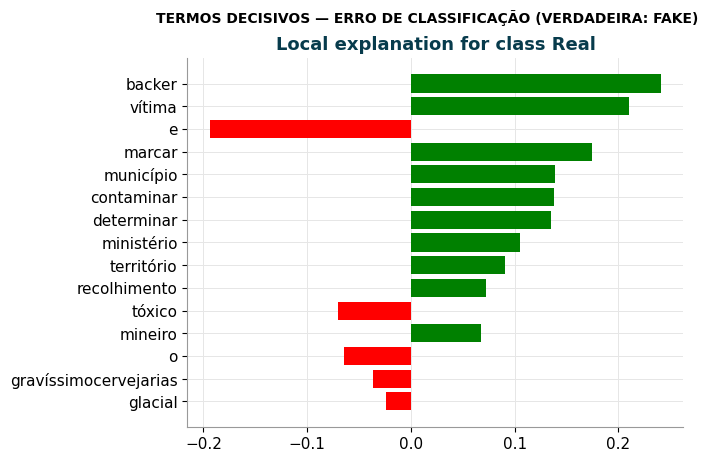

In [11]:
amostra = df.sample(200, random_state=42)
probs = prever_proba(amostra["Noticia"].tolist())
preds = probs.argmax(axis=1)

erros = amostra[preds != amostra["Classe"].values]
print(f"{len(erros)} erros em 200 amostras")

if len(erros) > 0:
    texto_erro = erros["Noticia"].iloc[0]
    classe_verdadeira = "Real" if erros["Classe"].iloc[0] == 1 else "Fake"
    print(f"Classe verdadeira: {classe_verdadeira}\n")
    exp_erro = explicador.explain_instance(texto_erro, prever_proba, num_features=15, num_samples=500)
    fig = exp_erro.as_pyplot_figure()
    fig.suptitle(f"TERMOS DECISIVOS — ERRO DE CLASSIFICAÇÃO (VERDADEIRA: {classe_verdadeira.upper()})",
                 fontsize=10, fontweight="bold")
    fig.savefig(f"{BASE}/figuras/lime_exemplo_erro.png", dpi=300, bbox_inches="tight")
    plt.show()

## 4. Consolidação dos resultados

In [12]:
import pandas as pd, os

resultados = pd.read_csv(f"{BASE}/dados/resultados_classificacao.csv")

# Fase 5 — previsões do BERTimbau
caminho_bert = f"{BASE}/dados/previsoes_bertimbau.csv"
if os.path.exists(caminho_bert):
    bert = pd.read_csv(caminho_bert)
    resultados["previsao_bertimbau"] = bert["previsao_bertimbau"].values
    resultados["acertou_bert"] = resultados["classe_real"] == resultados["previsao_bertimbau"]
    print("Previsões do BERTimbau incorporadas.")
else:
    print("previsoes_bertimbau.csv não encontrado — execute a Fase 5.")

acuracias = {
    "LOGISTIC REGRESSION": resultados["acertou_lr"].mean(),
    "RANDOM FOREST": resultados["acertou_rf"].mean(),
}
if "acertou_bert" in resultados.columns:
    acuracias["BERTIMBAU"] = resultados["acertou_bert"].mean()

for k, v in acuracias.items():
    print(f"{k}: {v:.4f}")

Previsões do BERTimbau incorporadas.
LOGISTIC REGRESSION: 0.9437
RANDOM FOREST: 0.9374
BERTIMBAU: 0.9740


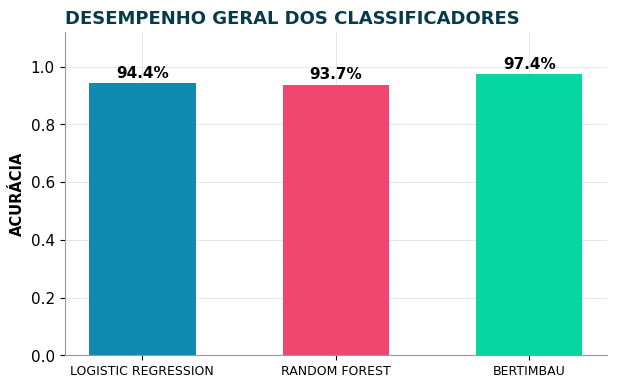

In [13]:
def grafico_comparacao_modelos():
    fig, ax = plt.subplots(figsize=(7, 4.2))
    cores = [AZUL, CORAL, VERDE][:len(acuracias)]
    barras = ax.bar(list(acuracias.keys()), list(acuracias.values()), color=cores, width=0.55)
    for barra in barras:
        h = barra.get_height()
        ax.annotate(f"{h:.1%}", xy=(barra.get_x() + barra.get_width()/2, h),
                    xytext=(0, 4), textcoords="offset points", ha="center",
                    fontsize=11, fontweight="bold")
    ax.set_ylabel("ACURÁCIA")
    ax.set_title("DESEMPENHO GERAL DOS CLASSIFICADORES", loc="left")
    ax.set_ylim(0, 1.12)
    plt.xticks(fontsize=9)
    return fig

fig = grafico_comparacao_modelos()
fig.savefig(f"{BASE}/figuras/comparacao_geral_modelos.png")
plt.show()

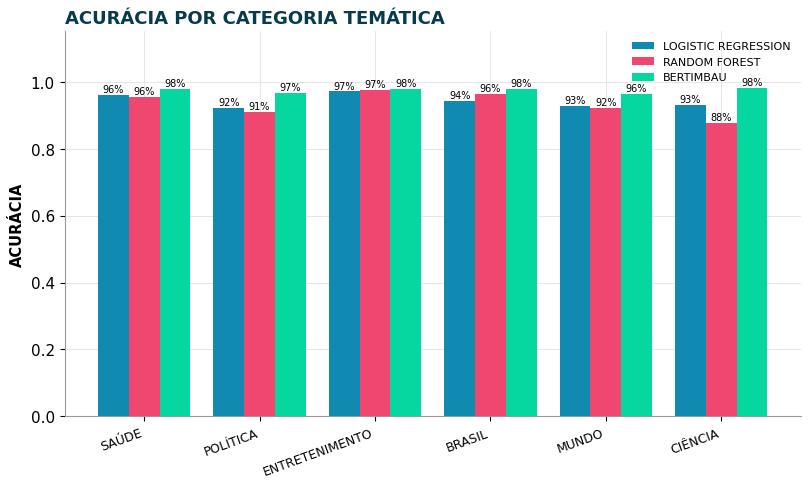

In [14]:
def grafico_por_categoria():
    cols = {"acuracia_lr": ("acertou_lr", "LOGISTIC REGRESSION", AZUL),
            "acuracia_rf": ("acertou_rf", "RANDOM FOREST", CORAL)}
    if "acertou_bert" in resultados.columns:
        cols["acuracia_bert"] = ("acertou_bert", "BERTIMBAU", VERDE)

    agg = {k: (v[0], "mean") for k, v in cols.items()}
    agg["n"] = ("classe_real", "size")
    tab = resultados.groupby("categoria").agg(**agg).reset_index().sort_values("n", ascending=False)

    x = np.arange(len(tab))
    largura = 0.8 / len(cols)
    fig, ax = plt.subplots(figsize=(9.5, 5))
    for i, (chave, (_, rotulo, cor)) in enumerate(cols.items()):
        desloc = (i - (len(cols)-1)/2) * largura
        barras = ax.bar(x + desloc, tab[chave], largura, label=rotulo, color=cor)
        for barra in barras:
            h = barra.get_height()
            ax.annotate(f"{h:.0%}", xy=(barra.get_x()+barra.get_width()/2, h),
                        xytext=(0, 2), textcoords="offset points", ha="center", fontsize=7)
    ax.set_ylabel("ACURÁCIA")
    ax.set_title("ACURÁCIA POR CATEGORIA TEMÁTICA", loc="left")
    ax.set_xticks(x)
    ax.set_xticklabels([c.upper() for c in tab["categoria"]], rotation=20, ha="right", fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=8)
    return fig

fig = grafico_por_categoria()
fig.savefig(f"{BASE}/figuras/comparacao_categoria_3modelos.png")
plt.show()

### Robustez frente à desinformação sintética

Compara o desempenho no conjunto de teste original com a taxa de detecção das notícias geradas por modelo de linguagem (Fase 6). Este é o resultado central do trabalho: quantifica em que medida classificadores treinados em desinformação de produção humana permanecem eficazes diante de conteúdo sintético.

                modelo  acuracia_original  deteccao_sintetica
0  Logistic Regression              0.944            0.646259
1        Random Forest              0.937            0.482993
2            BERTimbau              0.000            0.204082


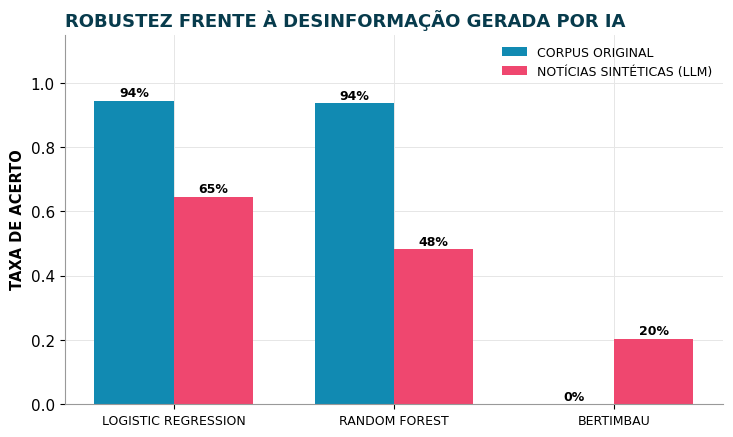

In [15]:
caminho_det = f"{BASE}/dados/deteccao_sinteticas.csv"

if os.path.exists(caminho_det):
    det = pd.read_csv(caminho_det)
    print(det)

    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    x = np.arange(len(det))
    largura = 0.36
    ax.bar(x - largura/2, det["acuracia_original"], largura,
           label="CORPUS ORIGINAL", color=AZUL)
    ax.bar(x + largura/2, det["deteccao_sintetica"], largura,
           label="NOTÍCIAS SINTÉTICAS (LLM)", color=CORAL)

    for i, linha in det.iterrows():
        ax.annotate(f"{linha['acuracia_original']:.0%}", xy=(i - largura/2, linha["acuracia_original"]),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9, fontweight="bold")
        ax.annotate(f"{linha['deteccao_sintetica']:.0%}", xy=(i + largura/2, linha["deteccao_sintetica"]),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9, fontweight="bold")

    ax.set_ylabel("TAXA DE ACERTO")
    ax.set_title("ROBUSTEZ FRENTE À DESINFORMAÇÃO GERADA POR IA", loc="left")
    ax.set_xticks(x)
    ax.set_xticklabels([m.upper() for m in det["modelo"]], fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=9)
    fig.savefig(f"{BASE}/figuras/robustez_sintetica.png")
    plt.show()
else:
    print("deteccao_sinteticas.csv não encontrado — execute a célula de consolidação da Fase 6.")

## 5. Painel interativo

Aplicação em Gradio com três abas: classificação de textos com explicação LIME sob demanda, visualização dos resultados consolidados, e nota metodológica.

Substitui a etapa de visualização anteriormente prevista em ferramenta proprietária: roda no navegador a partir de um link, sem instalação, e seu código integra o mesmo repositório reprodutível do restante do trabalho.

In [16]:
import gradio as gr

def classificar(texto):
    if not texto or not texto.strip():
        return {"Digite um texto": 1.0}
    p = prever_proba([texto])[0]
    return {"Possivelmente FALSA": float(p[0]),
            "Possivelmente VERDADEIRA": float(p[1])}

def classificar_e_explicar(texto):
    if not texto or not texto.strip():
        return {"Digite um texto": 1.0}, "<p>Aguardando texto.</p>"
    p = prever_proba([texto])[0]
    rotulos = {"Possivelmente FALSA": float(p[0]),
               "Possivelmente VERDADEIRA": float(p[1])}
    exp = explicador.explain_instance(texto, prever_proba, num_features=12, num_samples=300)
    return rotulos, exp.as_html()

In [17]:
NOTA_METODOLOGICA = """
## Sobre este protótipo

Trabalho de Conclusão de Curso — Tecnologia em Análise e Desenvolvimento de Sistemas
Instituto Federal do Paraná (IFPR), Campus Paranaguá.

**Modelo:** BERTimbau (SOUZA; NOGUEIRA; LOTUFO, 2020) ajustado sobre o corpus
FakeRecogna (GARCIA; AFONSO; PAPA, 2022).

**Limitações declaradas:**

- O corpus apresenta diferença sistemática de tamanho entre as classes, o que
  configura risco de *shortcut learning* (GEIRHOS et al., 2020; HAROON et al., 2026).
- O treinamento concentra-se em verificações de um subconjunto de agências brasileiras
  de fact-checking; os padrões aprendidos refletem suas práticas editoriais.
- A robustez frente a desinformação gerada por modelos de linguagem foi avaliada com
  um único gerador, e não é possível generalizar o achado para outros modelos.

**Este é um protótipo acadêmico.** Não substitui a verificação humana realizada por
agências profissionais de fact-checking, e não deve ser usado como critério único
para julgar a veracidade de uma informação.
"""

with gr.Blocks(title="Detecção de Fake News em Português") as demo:
    gr.Markdown("# Detecção de Fake News em Português\n"
                "### Protótipo acadêmico — BERTimbau ajustado sobre o corpus FakeRecogna")

    with gr.Tab("Classificador"):
        entrada = gr.Textbox(lines=10, label="Texto da notícia",
                             placeholder="Cole aqui o texto de uma notícia...")
        with gr.Row():
            btn_rapido = gr.Button("Classificar", variant="primary")
            btn_explicar = gr.Button("Classificar e explicar (mais lento)")
        saida_rotulo = gr.Label(num_top_classes=2, label="Classificação")
        saida_exp = gr.HTML(label="Termos decisivos (LIME)")

        btn_rapido.click(classificar, inputs=entrada, outputs=saida_rotulo)
        btn_explicar.click(classificar_e_explicar, inputs=entrada,
                           outputs=[saida_rotulo, saida_exp])

    with gr.Tab("Resultados"):
        gr.Markdown("### Desempenho comparativo dos classificadores")
        gr.Plot(grafico_comparacao_modelos(), label="Desempenho geral")
        gr.Plot(grafico_por_categoria(), label="Por categoria temática")

    with gr.Tab("Metodologia"):
        gr.Markdown(NOTA_METODOLOGICA)

demo.launch(share=True, inline=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0dcbc14c50057672b7.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Figuras geradas nesta fase

| Arquivo | Uso sugerido no artigo |
|---|---|
| `lime_exemplo_fake.png` | Explicabilidade — acerto em notícia falsa |
| `lime_exemplo_real.png` | Explicabilidade — acerto em notícia verdadeira |
| `lime_exemplo_erro.png` | Explicabilidade — análise de erro |
| `comparacao_geral_modelos.png` | Resultados — desempenho das três abordagens |
| `comparacao_categoria_3modelos.png` | Resultados — desempenho por tema |
| `robustez_sintetica.png` | Resultados — robustez frente à IA generativa |

